In [89]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from scipy.ndimage import median_filter
import tifffile as tiff

In [90]:
#Set frame rate
f = 2 # Hz
#Set loop area size (+/-pixels)
loop_area = 6
#Set DNA intensity threshold for DNA ends determination
DNA_intensity_threshold = 2 #times background noise

In [91]:
#FUNCTIONS

# Find DNA ends 
def find_DNA_ends(frames_no_LE, file_name):
    file = tiff.imread(file_name)
    file = np.array(file)
    file = np.transpose(file)
    pixels = np.zeros(len(file[0]))
    for line in file[min(frames_no_LE):max(frames_no_LE)]: 
        for index, x in enumerate(line):
            pixels[index] = pixels[index]+line[index]
    pixels = pixels/len(frames_no_LE)
    pixels_mf = median_filter(pixels, size=3, cval=0, mode='constant')
    background =np.min(pixels_mf)
    pixels = pixels - background
    indices = [i for i,v in enumerate(pixels) if v>= 2*background]
    DNA_ends=[min(indices),max(indices)]
    plt.figure(figsize = (4,2))
    plt.plot(pixels, linewidth = 2)
    plt.axvline(x = DNA_ends[0], color = 'red', ls = '--', alpha=0.5)
    plt.axvline(x = DNA_ends[1], color = 'red', ls = '--', alpha=0.5)
    plt.xlabel("Pixels")
    plt.ylabel("Intensity (a.u)")
    plt.title("Average DNA profile without loop")
    plt.show()
    return DNA_ends
    

# Calculate loop size 
def loop(loop_profile, DNA_ends, max_pos):
    #calculate background and correct
    loop_profile_mf = median_filter(loop_profile, size=3, cval=0, mode='constant')
    background =np.min(loop_profile_mf)
    loop_profile = loop_profile - background
    loop_profile[loop_profile < 0] = 0
    
    #only DNA profile (remove extra pixels)
    for i in range(len(loop_profile[:DNA_ends[0]])-1):
        if loop_profile[DNA_ends[0]-i-1]>loop_profile[DNA_ends[0]-i]:
            loop_profile[:(DNA_ends[0]-i-1)]=0
    for i in range(len(loop_profile[DNA_ends[1]:])-1):
        if loop_profile[DNA_ends[1]+i+1]>loop_profile[DNA_ends[1]+i]:
            loop_profile[(DNA_ends[1]+i+1):]=0

    #Create pixels array
    k = 0
    pixels = np.arange(len(loop_profile))

    #calculate DNA inside the loop
    total_intensity = sum(loop_profile)
    loop_intensity = sum(loop_profile[int(max_pos-loop_area):int(max_pos+loop_area+1)])
    DNA_up_intensity = sum(loop_profile[:int(max_pos-loop_area)])
    DNA_down_intensity = sum(loop_profile[int(max_pos+loop_area+1):])
    if (DNA_ends[0]+loop_area) >= max_pos:
        outside_loop = loop_profile[int(max_pos+loop_area+1):DNA_ends[1]]
    elif (DNA_ends[1]-loop_area) <= max_pos:
        outside_loop = loop_profile[DNA_ends[0]:int(max_pos-loop_area)]
    else:
        outside_loop = np.r_[loop_profile[DNA_ends[0]:int(max_pos-loop_area)],loop_profile[int(max_pos+loop_area+1):(DNA_ends[1]+1)]]

    #correct for DNA outside the loop in the "loop" segment
    loop_intensity = loop_intensity - np.mean(outside_loop)*(2*loop_area+1)
    DNA_down_intensity = DNA_down_intensity + 0.5*np.mean(outside_loop)*(2*loop_area+1)
    DNA_up_intensity = DNA_up_intensity + 0.5*np.mean(outside_loop)*(2*loop_area+1)
    outside_loop_mean_intensity = np.mean(outside_loop)

    #recalculate into kbps
    loop_kbp = loop_intensity*48.5/total_intensity
    DNA_down_kbp = DNA_down_intensity*48.5/total_intensity
    DNA_up_kbp = DNA_up_intensity*48.5/total_intensity

    return loop_kbp, DNA_down_kbp, DNA_up_kbp, loop_profile, outside_loop_mean_intensity

# plot graphs and extract LE rate by linear fit
def LE_rate_fit_and_plot(file_name, DNA_ends, frames_LE, seconds_fit, frame):
    file = tiff.imread(file_name)
    file = np.array(file)
    file = np.transpose(file)
    file_mf = median_filter(file, size=3, cval=0, mode='constant')
    name = file_name.split(".")
    name = name[0]
    loop_size = []
    outside_loop_up = []
    outside_loop_down = []
    maximum_list = []
    if frames_LE[1]>len(file):
        frames_LE[1]=len(file)

    
    #plot kymograph
    plt.figure(figsize = (10,2))
    figure0 = plt.imshow(np.transpose(file), cmap=plt.cm.twilight_shifted)
    plt.colorbar(fraction=0.01, pad=0.04)
    loop_frames = np.arange(frames_LE[0],frames_LE[1],1)
    #plt.scatter(loop_frames, maximum_list[frames_LE[0]:frames_LE[1]], s=1, alpha=0.5, color = 'r')
    #plt.plot(loop_frames, maximum_list[frames_LE[0]:frames_LE[1]], linewidth=(1+loop_area), alpha=0.3, color = 'orange')
    plt.xlabel("Frames")
    plt.ylabel("Pixels")
    plt.title("Kymograph")
    plt.show()
    
    #plot LE graphs
    i = 0
    for line in file:    
        max_pos = np.argmax(file[i])
        i=i+1
        Loop_kbp, DNA_intesity_down, DNA_intesity_up, loop_profile, DNA_mean_intensity = loop(line,DNA_ends,max_pos)
        loop_size.append(Loop_kbp)
        outside_loop_up.append(DNA_intesity_up)
        outside_loop_down.append(DNA_intesity_down)
        maximum_list.append(max_pos)
    time = np.arange(len(loop_size))/f

    figure, axis = plt.subplots(1,2)
    figure.set_size_inches(12, 3)
    axis[0].plot(time, loop_size, label = "Loop size (kbp)")
    axis[0].plot(time, outside_loop_up, label = "DNA top")
    axis[0].plot(time, outside_loop_down, label = "DNA bottom")
    axis[0].legend(loc="upper left")
    axis[0].set_xlabel('Time (s)')
    axis[0].set_ylabel('DNA (kbp)')
    axis[0].set_title("Kymograph tracking")
    
    #plot DNA profile
    max_pos = np.argmax(file[frame])
    Loop_kbp, DNA_intesity_down, DNA_intesity_up, loop_profile, DNA_mean_intensity = loop(file[frame],DNA_ends, max_pos)
    
    #fill loop area
    linewidth = 2.5
    x_plot = np.arange((max_pos-loop_area),(max_pos+loop_area+1))
    y_plot = loop_profile[int(max_pos-loop_area):int(max_pos+loop_area+1)]
    for i in range(len(x_plot)):
        axis[1].vlines(x = x_plot[i], color = 'lightskyblue', ymin = 0, ymax = y_plot[i], linewidth = linewidth)  

    #fill "top" area
    loop_profile[:int(max_pos-loop_area)]
    x_plot = np.arange(max_pos-loop_area)
    y_plot = loop_profile[:int(max_pos-loop_area)]
    for i in range(len(x_plot)):
        axis[1].vlines(x = x_plot[i], color = 'orange', ymin = 0, ymax = y_plot[i], linewidth = linewidth) 
    x_plot = np.arange(max_pos-loop_area, max_pos)
    for i in range(loop_area):
        axis[1].vlines(x = x_plot[i], color = 'orange', ymin = 0, ymax = DNA_mean_intensity, linewidth = linewidth) 

    #fill "bottom" area
    loop_profile[:int(max_pos-loop_area)]
    x_plot = np.arange((max_pos+loop_area+1), len(loop_profile))
    y_plot = loop_profile[int(max_pos+loop_area+1):]
    for i in range(len(x_plot)):
        axis[1].vlines(x = x_plot[i], color = 'forestgreen', ymin = 0, ymax = y_plot[i], linewidth = linewidth)  
    x_plot = np.arange(max_pos+1, max_pos+loop_area+1)
    for i in range(loop_area):
        axis[1].vlines(x = x_plot[i], color = 'forestgreen', ymin = 0, ymax = DNA_mean_intensity, linewidth = linewidth) 

    #plot DNA ends and loop position
    axis[1].axvline(x = DNA_ends[0], color = 'r', ls = '--', alpha=0.5)
    axis[1].axvline(x = DNA_ends[1], color = 'r', ls = '--', alpha=0.5)
    axis[1].set_xlabel('Pixels')
    axis[1].set_ylabel('Intensity (a.u.)')
    axis[1].axvline(x = max_pos, color = 'red', ls = '--', alpha=0.5)
    axis[1].plot(loop_profile, linewidth = 2)
    axis[1].set_title("Selected DNA profile")
    plt.show()
    
    #LE rate 
    figure2, axis = plt.subplots(1,3, gridspec_kw={'width_ratios': [2,2,2]})
    figure2.set_size_inches(12, 3)
    #plot raw data
    axis[0].scatter(time, loop_size, label = "Loop size (kbp)",s=10, alpha=0.5)
    axis[0].scatter(time, outside_loop_up, label = "DNA top",s=10, alpha=0.5)
    axis[0].scatter(time, outside_loop_down, label = "DNA bottom",s=10, alpha=0.5)
    #plot smoothed
    axis[0].plot(time, savgol_filter(loop_size,15,1), linewidth=3.0)
    axis[0].plot(time, savgol_filter(outside_loop_up,15,1), linewidth=3.0)
    axis[0].plot(time, savgol_filter(outside_loop_down,15,1), linewidth=3.0)
    axis[0].legend(loc="upper left")
    axis[0].set_xlabel('Time (s)')
    axis[0].set_ylabel('DNA (kbp)')
    axis[0].set_xlim(frames_LE[0]/f,frames_LE[1]/f)
    axis[0].set_ylim(0,48)
    axis[0].set_title("Loop area tracking")
    
    #LE rate fitting
    axis[1].scatter(time, loop_size, s=10, alpha=0.5)
    axis[1].plot(time, savgol_filter(loop_size,15,1), linewidth=3.0)
    axis[1].legend(loc="upper left")
    axis[1].set_xlabel('Time (s)')
    axis[1].set_ylabel('DNA (kbp)')
    axis[1].set_xlim(frames_LE[0]/f,frames_LE[1]/f)
    axis[1].set_ylim(0,)
    
    index1 = np.argmin(np.abs(np.array(time)-seconds_fit[0]))
    index2 = np.argmin(np.abs(np.array(time)-seconds_fit[1]))
    x = time[index1:index2]
    y = loop_size[index1:index2]
    k_loop,b = np.polyfit(x, y, 1) 
    y_fit = b + k_loop*x
    axis[1].plot(x, y_fit, color = 'r', label=("Linear fit: "+str(round(k_loop,3))+" kbp/s"),linewidth=3.0, alpha=0.5)
    axis[1].legend(loc="upper left")
    axis[1].set_title("LE rate linear fit")
    
    #Top DNA incorporation fitting
    axis[2].scatter(time, outside_loop_up, s=10, alpha=0.5, color='darkorange')
    axis[2].plot(time, savgol_filter(outside_loop_up,15,1), linewidth=3.0, color='darkorange')
    y = outside_loop_up[index1:index2]
    k_top,b = np.polyfit(x, y, 1) 
    y_fit = b + k_top*x
    axis[2].plot(x, y_fit, color = 'r', label=("Top: "+str(-round(k_top,3))+" kbp/s"),linewidth=3.0, alpha=0.5)
    
    #Bottom DNA incorporation fitting
    axis[2].scatter(time, outside_loop_down, s=10, alpha=0.5, color='forestgreen')
    axis[2].plot(time, savgol_filter(outside_loop_down,15,1), linewidth=3.0, color='forestgreen')
    axis[2].set_xlabel('Time (s)')
    axis[2].set_ylabel('DNA (kbp)')
    axis[2].set_xlim(frames_LE[0]/f,frames_LE[1]/f)
    axis[2].set_ylim(0,48)
    y = outside_loop_down[index1:index2]
    k_bottom,b = np.polyfit(x, y, 1) 
    y_fit = b + k_bottom*x
    axis[2].plot(x, y_fit, color = 'black', label=("Bottom: "+str(-round(k_bottom,3))+" kbp/s"),linewidth=3.0, alpha=0.5)
    axis[2].legend(loc="best")
    axis[2].set_title("Top/Bottom DNA")
    plt.show()


    #plot kymograph (only selected LE range )
    plt.figure(figsize = (10,2))
    figure0 = plt.imshow(np.transpose(file), cmap=plt.cm.twilight_shifted)
    plt.colorbar(fraction=0.01, pad=0.04)
    loop_frames = np.arange(frames_LE[0],frames_LE[1],1)
    plt.scatter(loop_frames, maximum_list[frames_LE[0]:frames_LE[1]], s=1, alpha=0.5, color = 'r')
    plt.plot(loop_frames, maximum_list[frames_LE[0]:frames_LE[1]], linewidth=(1+loop_area), alpha=0.3, color = 'orange')
    plt.xlim(frames_LE[0]-10, frames_LE[1]+10)
    plt.xlabel("Frames")
    plt.ylabel("Pixels")
    plt.title("Loop area tracking")
    plt.show()
        
    return time, loop_size, outside_loop_down, outside_loop_up, k_loop


1x, 2Hz, example kymo.tif


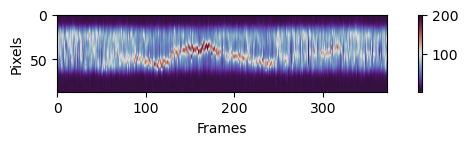

1x, 2Hz, example kymo2.tif


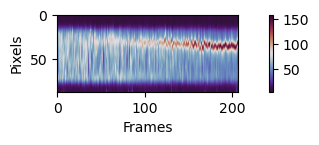

In [92]:
#plot all kymographs in the folder and form a list
filenames = sorted(os.listdir()) #Sorted based on file names
tiff_list =[]
for x in filenames:
    if x.endswith("tif"):
        print(x)
        # Read TIFF as numpy array
        img = tiff.imread(x)
        img = np.array(img)
        
        # Plot kymograph
        plt.figure(figsize = (10,1))
        figure = plt.imshow(img, cmap=plt.cm.twilight_shifted)
        plt.colorbar(fraction=0.01, pad=0.04)
        plt.xlabel("Frames")
        plt.ylabel("Pixels")
        plt.show()
        tiff_list.append(x)

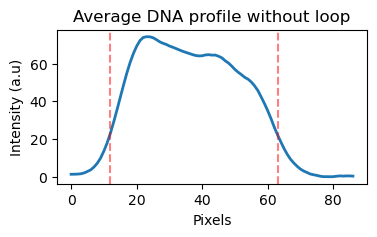

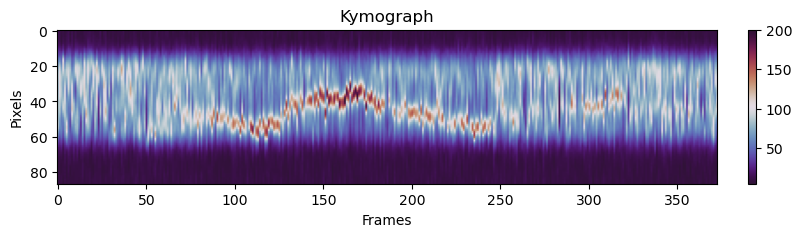

/var/folders/mb/kk08y29x5hg2jvyg6329m5f00000gp/T/ipykernel_17508/2149448111.py:50: RuntimeWarning: overflow encountered in scalar add
  total_intensity = sum(loop_profile)
/var/folders/mb/kk08y29x5hg2jvyg6329m5f00000gp/T/ipykernel_17508/2149448111.py:52: RuntimeWarning: overflow encountered in scalar add
  DNA_up_intensity = sum(loop_profile[:int(max_pos-loop_area)])


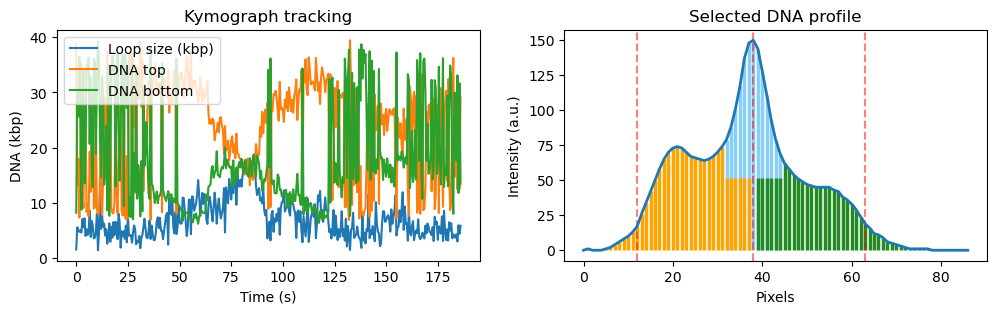

/var/folders/mb/kk08y29x5hg2jvyg6329m5f00000gp/T/ipykernel_17508/2149448111.py:186: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axis[1].legend(loc="upper left")


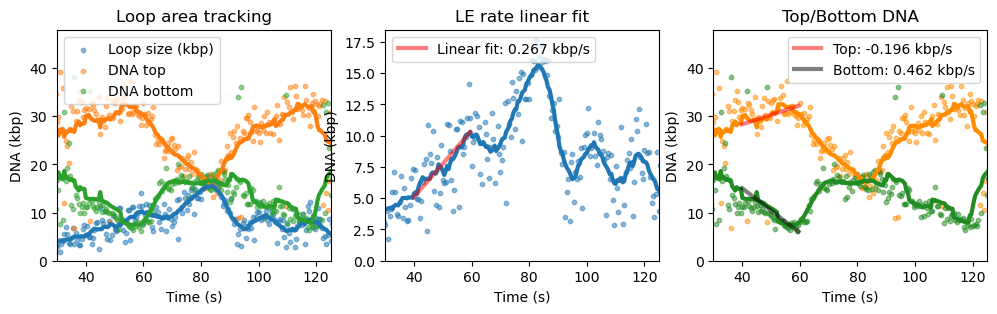

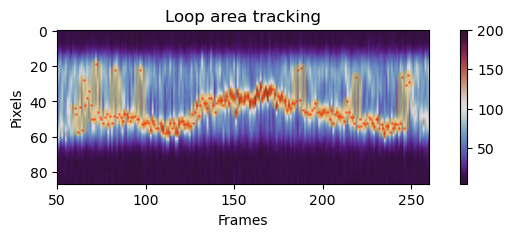

In [93]:
#process one kymograph (select file from the list of kymographs)
file_number = 0
file = tiff_list[file_number]

# select non-looping and looping frames
frames_no_LE = np.arange(0,30,1)
frames_LE = [60,250]

# select frames for linear fit
seconds_fit = [40,60]

# select a frame to plot DNA profile
frame = 150

DNA_ends = find_DNA_ends(frames_no_LE, file)
#DNA_ends = [10,30] # use manual DNA ends selection if automatic fails
time, loop_size, outside_loop_down, outside_loop_up, LE_rate = LE_rate_fit_and_plot(file,DNA_ends, frames_LE,seconds_fit,frame)

# export results in txt
file_name_split = file.split(".tif")
file_name_no_ext = file_name_split[0]
start = frames_LE[0]
stop = frames_LE[1]
export = np.column_stack((time[start:stop], loop_size[start:stop], outside_loop_up[start:stop], outside_loop_down[start:stop]))
#Create output folder
if not os.path.exists("txt_export"):
    os.makedirs("txt_export")
np.savetxt(("txt_export/"+file_name_no_ext+"(Time, Loop, Up, Down).txt"), export)

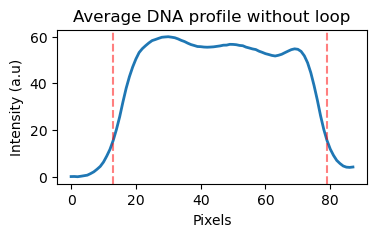

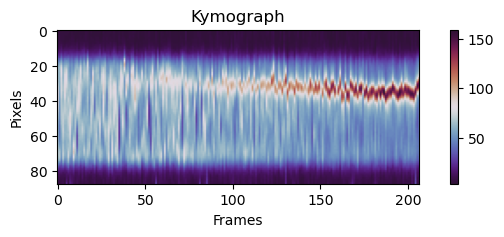

/var/folders/mb/kk08y29x5hg2jvyg6329m5f00000gp/T/ipykernel_17508/2149448111.py:50: RuntimeWarning: overflow encountered in scalar add
  total_intensity = sum(loop_profile)
/var/folders/mb/kk08y29x5hg2jvyg6329m5f00000gp/T/ipykernel_17508/2149448111.py:52: RuntimeWarning: overflow encountered in scalar add
  DNA_up_intensity = sum(loop_profile[:int(max_pos-loop_area)])


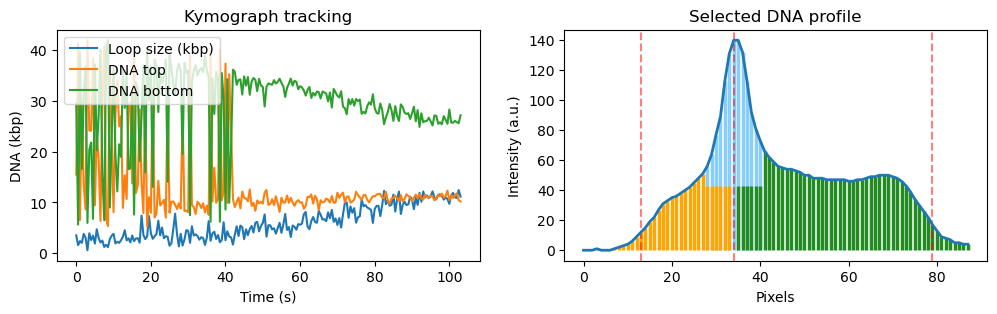

/var/folders/mb/kk08y29x5hg2jvyg6329m5f00000gp/T/ipykernel_17508/2149448111.py:186: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axis[1].legend(loc="upper left")


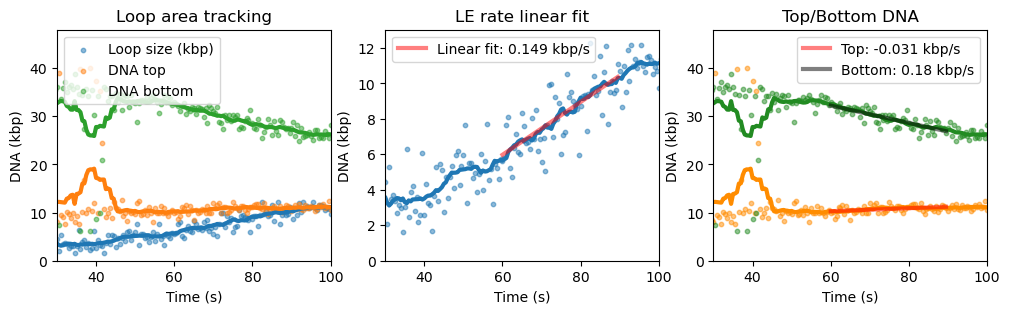

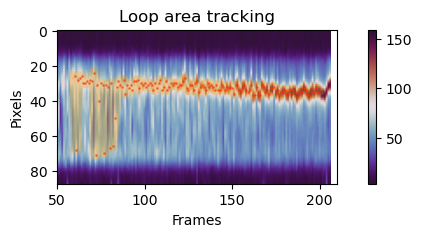

In [94]:
#process one kymograph (select file from the list of kymographs)
file_number = 1
file = tiff_list[file_number]

# select non-looping and looping frames
frames_no_LE = np.arange(0,30,1)
frames_LE = [60,200]

# select frames for linear fit
seconds_fit = [60,90]

# select a frame to plot DNA profile
frame = 200

DNA_ends = find_DNA_ends(frames_no_LE, file)
#DNA_ends = [10,30] # use manual DNA ends selection if automatic fails
time, loop_size, outside_loop_down, outside_loop_up, LE_rate = LE_rate_fit_and_plot(file,DNA_ends, frames_LE,seconds_fit,frame)

# export results in txt
file_name_split = file.split(".tif")
file_name_no_ext = file_name_split[0]
start = frames_LE[0]
stop = frames_LE[1]
export = np.column_stack((time[start:stop], loop_size[start:stop], outside_loop_up[start:stop], outside_loop_down[start:stop]))
#Create output folder
if not os.path.exists("txt_export"):
    os.makedirs("txt_export")
np.savetxt(("txt_export/"+file_name_no_ext+"(Time, Loop, Up, Down).txt"), export)